# 03 — Relajación Lagrangiana HDM

Análisis de la **relajación lagrangiana** del modelo HDM (*Household-oriented
Deterministic Model*) para la localización de puntos de recogida en San Cristóbal de La
Laguna. Se relajan las restricciones de acoplamiento y capacidad, y el dual se optimiza
por **método del subgradiente** (Li et al., 2026), que da una **cota inferior (LB)**; una
heurística de reparación + pulido da la **cota superior (UB)**.

El cuaderno se apoya por completo en la librería `analisis` (**narrativa + llamadas**,
sin lógica inline). Hay **un solo tamaño resuelto (500 m)** — no hay barrido, luego **no
hay estudio de escalabilidad** (un punto no es tendencia, D9); la comparación
multi-método completa es el cuaderno 05. Las soluciones se cargan del *layout viejo*
(`output/lagrangiana_500m/…` y `output/exacto_500m/…` como referencia) hasta la Fase E.

In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, "../src/python")   # mínimo para importar 'analisis' (patrón 01/02)

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, Markdown

from instancia import load_instance
from analisis import carga, estilo, rutas, metricas, comparativas
# 'mapas' (osmnx/geopandas) se importa en §5, NO aquí: mantiene geo-free el resto.

TAM = 500                     # único tamaño lagrangiano resuelto (muestra D9 ∩ artefactos)
RAIZ = rutas.raiz_repo()

# Layout viejo (D6): ficheros aún sin migrar al esquema de rutas.py.
ruta_lr = RAIZ / "output" / f"lagrangiana_{TAM}m" / "solucion_lagrangiana.json"
ruta_ex = RAIZ / "output" / f"exacto_{TAM}m" / "solucion_exacta.json"

inst   = load_instance(str(rutas.ruta_instancia(TAM)))
sol_lr = comparativas.Solucion("lagrangiana", TAM, carga.cargar_solucion(str(ruta_lr)), inst)
sol_ex = comparativas.Solucion("exacto",      TAM, carga.cargar_solucion(str(ruta_ex)), inst)

d = sol_lr.datos
print(f"Lagrangiana {TAM}m: coste(UB)={metricas.coste(d):,.0f} €  |  "
      f"best_lb={d['best_lb']:,.1f}  |  gap_LR={metricas.gap(d):.2%}  |  "
      f"iters={d['n_iterations']}  |  runtime={d['runtime']:.1f}s")
print(f"Exacto {TAM}m (referencia): coste={metricas.coste(sol_ex.datos):,.0f} €")

Lagrangiana 500m: coste(UB)=343,070 €  |  best_lb=297,248.7  |  gap_LR=13.36%  |  iters=4000  |  runtime=566.4s
Exacto 500m (referencia): coste=343,070 €


## 2. Resultados: tabla híbrida

Tres vistas complementarias del caso 500 m:
1. **Agnóstica** (`comparativas.tabla_resumen`): coste, gap, tiempo, puntos y
   contenedores, con las **mismas** columnas para exacto y lagrangiana.
2. **Específica de la lagrangiana** (leída de la solución, *glue* de presentación): cotas
   `best_lb`/`best_ub`, `gap_LR`, nº de iteraciones y motivo de parada del subgradiente.
3. **Distancia al óptimo** (`comparativas.comparar_metodos`, referencia = exacto):
   `gap_vs_ref = (UB_LR − óptimo) / óptimo`.

,metodo,tam,coste,n_puntos,n_bins,gap,tiempo
0,exacto,500,343070.0,64,208,0.000087,705.619657
1,lagrangiana,500,343070.0,64,208,0.133562,566.419244


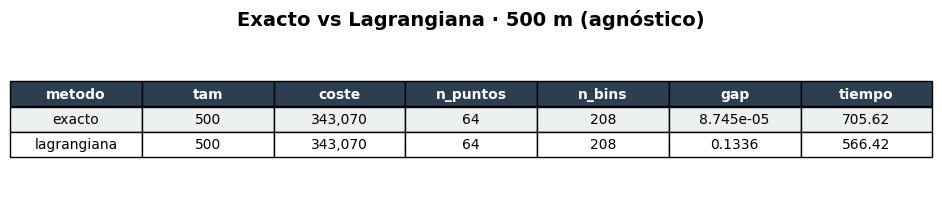

In [3]:
# (a) Tabla AGNÓSTICA: mismas columnas para exacto y lagrangiana.
df = comparativas.tabla_resumen([sol_ex, sol_lr])
display(df)

ax = comparativas.tabla_matplotlib(df, titulo="Exacto vs Lagrangiana · 500 m (agnóstico)")
ruta = rutas.ruta_figura("03_tabla_resumen")
ruta.parent.mkdir(parents=True, exist_ok=True)
ax.figure.savefig(ruta, dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
# (b) Tabla ESPECÍFICA de la lagrangiana (glue de presentación: lee escalares crudos de
# la solución; NO toca la librería agnóstica).
d = sol_lr.datos
tabla_lr = pd.DataFrame([{
    "best_lb (€)":  d["best_lb"],
    "best_ub (€)":  d["best_ub"],
    "gap_LR":       metricas.gap(d),
    "n_iterations": d["n_iterations"],
    "stop_reason":  d.get("stop_reason"),
}])
display(tabla_lr)

,best_lb (€),best_ub (€),gap_LR,n_iterations,stop_reason
0,297248.736493,343070.0,0.133562,4000,max_iters


In [ ]:
# (c) Distancia al óptimo: UB lagrangiano frente al óptimo exacto (gap_vs_ref).
comp = comparativas.comparar_metodos(
    {"lagrangiana": [sol_lr], "exacto": [sol_ex]}, referencia="exacto")
display(comp)

,tam,metodo,coste,coste_ref,referencia,gap_vs_ref
0,500,lagrangiana,343070.0,343070.0,exacto,0.0


## 3. Los dos gaps

La lagrangiana convive con **dos gaps distintos** que conviene no confundir: el **gap
interno** que ella misma reporta (UB − LB, su propia certificación) y la **distancia real
al óptimo** (UB frente al óptimo de Gurobi, que solo conocemos porque tenemos el exacto).
El contraste es el hallazgo central de este cuaderno.

In [ ]:
# Narrativa DINÁMICA: lee ambos gaps de las soluciones (no se clava ningún número).
d = sol_lr.datos
gap_lr   = metricas.gap(d)                 # gap interno (UB - LB)/UB
ub_lr    = d["best_ub"]
lb_lr    = d["best_lb"]
coste_ex = metricas.coste(sol_ex.datos)    # óptimo exacto (referencia)
dist_opt = (ub_lr - coste_ex) / coste_ex   # distancia REAL al óptimo

display(Markdown(
    f"**Los dos gaps.** La relajación reporta un **gap interno del {gap_lr:.2%}**: la "
    f"distancia entre su cota superior (UB = {ub_lr:,.0f} €) y su cota inferior "
    f"(LB = {lb_lr:,.0f} €). Es lo que el método **demuestra** por sí solo. Pero, "
    f"contrastando con el exacto, su **distancia real al óptimo es del {dist_opt:.2%}** "
    f"(UB_LR {ub_lr:,.0f} € frente al óptimo {coste_ex:,.0f} €). Es decir, la lagrangiana "
    f"**encontró el óptimo pero no pudo demostrar que lo fuera**: el gap interno es "
    f"**pesimista** — mide la **debilidad de la cota dual** (el LB se queda corto), no la "
    f"calidad de la solución."
))

**Los dos gaps.** La relajación reporta un **gap interno del 13.36%**: la distancia entre su cota superior (UB = 343,070 €) y su cota inferior (LB = 297,249 €). Es lo que el método **demuestra** por sí solo. Pero, contrastando con el exacto, su **distancia real al óptimo es del 0.00%** (UB_LR 343,070 € frente al óptimo 343,070 €). Es decir, la lagrangiana **encontró el óptimo pero no pudo demostrar que lo fuera**: el gap interno es **pesimista** — mide la **debilidad de la cota dual** (el LB se queda corto), no la calidad de la solución.

## 4. Convergencia (figura central)

Evolución de LB y UB por iteración del subgradiente, con el óptimo exacto como
referencia. El **eje X está en escala logarítmica**: el subgradiente converge de forma
sublineal (~1/k), así que casi toda la mejora del LB ocurre en las primeras iteraciones y
luego hay una cola larga y plana — el log expande el arranque y comprime la cola.

Figura guardada: output/figuras/03_convergencia.png


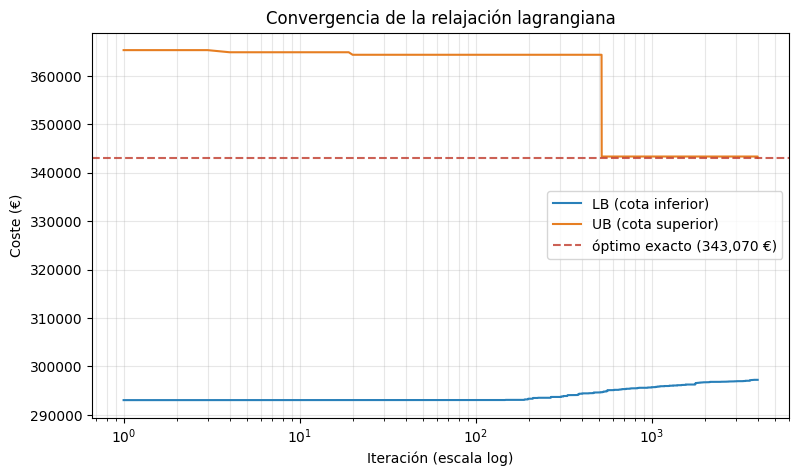

In [ ]:
ax = comparativas.grafico_convergencia(sol_lr)   # eje X log (mejora de la librería)
opt = metricas.coste(sol_ex.datos)
ax.axhline(opt, color="#c0392b", linestyle="--", alpha=0.8,
           label=f"óptimo exacto ({opt:,.0f} €)")
ax.legend()
ruta = rutas.ruta_figura("03_convergencia")
ruta.parent.mkdir(parents=True, exist_ok=True)
ax.figure.savefig(ruta, dpi=120, bbox_inches="tight")
print(f"Figura guardada: {ruta.relative_to(RAIZ)}")
plt.show()

## 5. Mapa de la solución (500 m)

Solución lagrangiana sobre el callejero con `mapas.mapa_solucion` (la **misma** función
única del cuaderno 02: la solución llega ya normalizada por `cargar_solucion`, sin nada
específico de método). Puntos abiertos con tamaño ∝ nº de contenedores y color ∝ demanda
asignada.

Figura guardada: output/figuras/03_solucion_500m.png


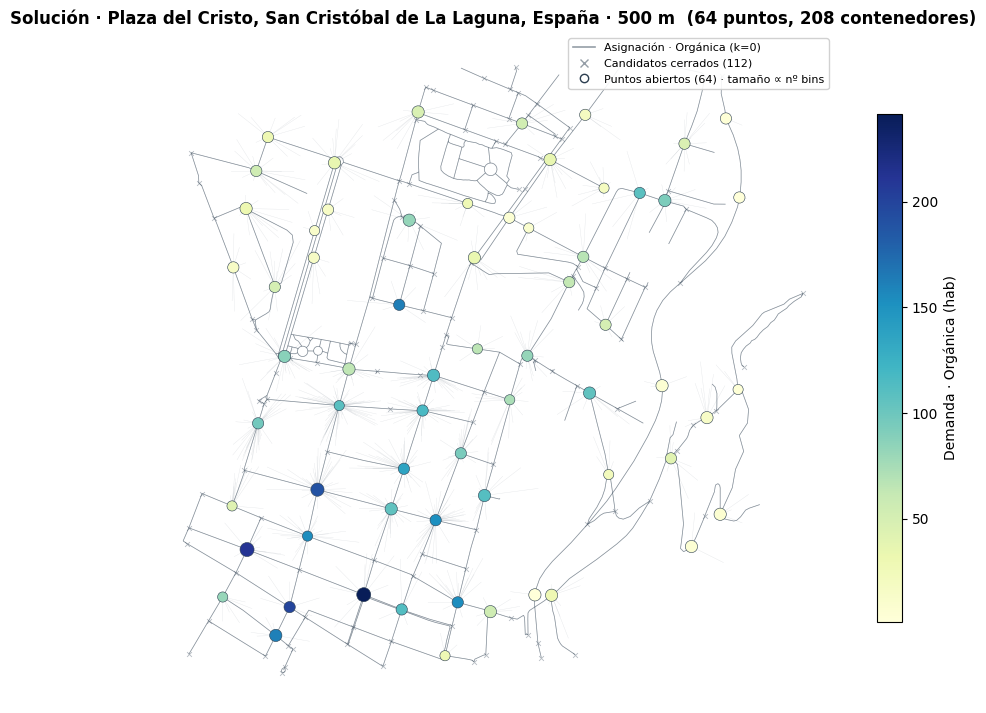

In [ ]:
# osmnx/geopandas se importan AQUÍ (no al top): así el resto del cuaderno se mantiene
# geo-free y solo pagamos la cartografía en esta celda.
from analisis import mapas

ax = mapas.mapa_solucion(sol_lr.datos, inst, rich=True)
ruta = rutas.ruta_figura(f"03_solucion_{TAM}m")
ruta.parent.mkdir(parents=True, exist_ok=True)
ax.figure.savefig(ruta, dpi=120, bbox_inches="tight")
print(f"Figura guardada: {ruta.relative_to(RAIZ)}")
plt.show()

## 6. Conclusiones

La relajación lagrangiana **encontró la solución óptima** del caso 500 m (su UB coincide
con el óptimo de Gurobi), pero **no pudo certificarla**: su cota dual (LB) se queda por
debajo, de modo que el **gap interno que reporta es pesimista** y mide la debilidad de la
cota, no la calidad de la solución (§3). La curva de convergencia (§4, eje log) muestra
que casi toda la mejora ocurre en las primeras iteraciones del subgradiente, con una cola
larga y plana donde el LB apenas progresa. Con un solo tamaño resuelto no hay estudio de
escalabilidad; el barrido queda pendiente y la comparación multi-método completa es el
objeto del cuaderno 05.